In [ ]:
from __future__ import annotations
from typing import Union
import random
import math

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Optional rustworkx support
try:
    import rustworkx as rx
    RxGraph = rx.PyGraph
except ImportError:
    rx = None
    RxGraph = tuple()

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RXGate
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_aer import Aer
from qiskit import transpile

# CPLEX import
from docplex.mp.model import Model
from quantum_greedy import quantum_vertex_greedy_minimum,quantum_vertex_greedy_maximum,Quadratic_quantum_greedy,Quadratic_rounding_quantum_greedy,Commuting_quantum_greedy_minimum,Commuting_quantum_greedy_maximum,Quadratic_quantum_greedy_maximum,Quadratic_quantum_greedy_minimum
from util_greedy import plot_graph,echo_commutator_circuit,echo_fidelity,mixer_fixed_beta,qubit_one_probabilities,mixer_from_graph,expectation_value_cost_shifted
from classical_heuristics_util import is_vertex_cover, local_search_vertex_cover, ga_vertex_cover,bp_vertex_cover_enforced,bp_decode_vertex_cover,bp_vertex_cover_decimation,bp_greedy_vertex_cover,greedy_optimize_classical_seq
from classical_runtime_guarantee_util import mvc_exact_cplex, mvc_lp_relaxation, greedy_degree_vertex_cover, greedy_edge_vertex_cover,mvc_primal_dual_weighted
import os
import pickle

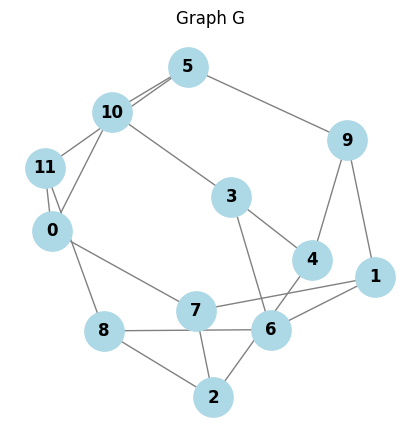

In [ ]:
G = nx.random_regular_graph(3,12)
#G = nx.barabasi_albert_graph(12,2)
#G=nx.erdos_renyi_graph(12,0.3)
c = {i: 1.0 for i in G.nodes()}
plot_graph(G)

In [ ]:
n=len(G.nodes())
C = {i: 1 for i in range(n)}
betas =  {i: np.pi/2 for i in range(n)}
energy = Quadratic_quantum_greedy_minimum(G,
                    C_builder=C,
                    beta_values_init=betas,
                    p=3,
                    shots=None)
print(energy)

TypeError: 'dict' object is not callable

In [ ]:
energy = Quadratic_quantum_greedy_maximum(G,
                    c,
                    np.pi/8,
                    betas_2=np.pi/2,
                    p=8,
                    shots=None)
print(energy)

In [ ]:
energy = Commuting_quantum_greedy_minimum(G,
                    c,
                    1,
                    betas_2=np.pi/2,
                    p=8,
                    shots=None)
print(energy)

0.6550964494450324 0
0.6482432714030533 1
0.6410999528391634 2
0.653203540751355 3
0.6484417584558428 4
0.6327431103556916 5
0.6380377142670531 6
0.6372056188749081 7
0.6350558397806483 8
0.6363821676212463 9
0.6537857998507213 10
0.6515144187484939 11
0.6552717369596116 0
0.7492718408809981 1
0.6411332288090309 2
0.6493944892632516 3
0.6486888549590376 4
0.746765133401075 6
0.7449407563149611 7
0.6350858728099049 8
0.636627406614323 9
0.6436929544760706 10
0.6460443951009226 11
0.7549977615512097 0
0.7494535960520331 1
0.7494136472090008 2
0.6441693653193644 3
0.6403909030622627 4
0.7471325297975403 6
0.7450695837475186 7
0.7451028694286982 9
0.6440014873045861 10
0.64221959642222 11
0.8689026884020399 0
0.7449097077046438 1
0.8615786578793883 2
0.7404097320708987 3
0.7475201907565691 6
0.745194381855135 7
0.735319678395472 9
0.6444993861734046 10
0.6380407056069978 11
0.9998250268804829 0
0.7404899892406205 1
0.8616768975043211 2
0.7406925136285126 3
0.859183374422819 6
0.73539101066

KeyboardInterrupt: 

In [ ]:
energy = Commuting_quantum_greedy_maximum(G,
                    c,
                    1,
                    betas_2=np.pi/2,
                    p=8,
                    shots=None)
print(energy)

In [ ]:
C_opt = mvc_exact_cplex(G, c)  # your exact MVC solver
opt_cost = sum(c[i] for i in C_opt)
print(opt_cost)

6.0


In [ ]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter

# -------------------------------------------------
# Experiment Parameters
# -------------------------------------------------
graph_sizes = [8, 10, 12, 14]
k = 10            # number of graph instances per size
degree = 3        # degree for random regular graphs
case = "unweighted"
shots = None

p_list = [1, 2, 3, 4]

beta_cases = {
    "beta=0.7": 0.5,
}

# -------------------------------------------------
# Storage
# -------------------------------------------------
approaches = []
for p in p_list:
    for beta_label in beta_cases:
        approaches.append(f"Quantum p={p} {beta_label}")

results_mean = {appr: [] for appr in approaches}
results_std = {appr: [] for appr in approaches}

# -------------------------------------------------
# Experiment Loop
# -------------------------------------------------
for n in graph_sizes:

    print("\nGraph size:", n)
    ratios = {appr: [] for appr in approaches}

    for graph_seed in range(k):
        print(graph_seed)

        # Alternatively, use random regular graph
        G = nx.random_regular_graph(degree, n, seed=graph_seed)

        # Node weights
        if case == "unweighted":
            c = {i: 1.0 for i in G.nodes()}
        else:
            c = {i: random.uniform(0.40, 0.70) for i in G.nodes()}

        # -------------------------------------------------
        # Optimal solution (placeholder, implement your exact solver)
        # -------------------------------------------------
        C_opt = mvc_exact_cplex(G, c)  # your exact MVC solver
        opt_cost = sum(c[i] for i in C_opt)

        # -------------------------------------------------
        # Quantum experiments
        # -------------------------------------------------
        for p in p_list:
            print(p)
            for beta_label, beta_val in beta_cases.items():

                # initialize beta_values and betas
                beta_values = {i: beta_val for i in c}  # same beta for all vertices
                betas = {i: Parameter(f"β_{i}") for i in range(len(G.nodes()))}

                energy = Commuting_quantum_greedy_minimum(G,
                    c,
                    3*np.pi,
                    betas_2=np.pi/2,
                    p=p,
                    shots=None)

                appr = f"Quantum p={p} {beta_label}"
                ratios[appr].append(energy / opt_cost)

    # -------------------------------------------------
    # Statistics
    # -------------------------------------------------
    for appr in approaches:
        results_mean[appr].append(np.mean(ratios[appr]))
        results_std[appr].append(np.std(ratios[appr]))

# -------------------------------------------------
# Plot Results
# -------------------------------------------------
plt.figure(figsize=(10,6))
for appr in approaches:
    plt.errorbar(graph_sizes, results_mean[appr], yerr=results_std[appr],
                 label=appr, marker='o', capsize=3)
plt.xlabel("Graph size (n)")
plt.ylabel("Energy / Optimum")
plt.title("Quantum Greedy MVC Performance for Fixed Betas")
plt.legend()
plt.grid(True)
plt.show()


Graph size: 8
0
1
1.0 0
1.0 1
1.0 2
1.0 3
1.0 4
1.0 5
1.0 6
1.0 7
No further non-commuting structure detected.
2
2.7733391199176163e-32 0
6.077163357286244e-64 1
2.7733391199176196e-32 2
3.798227098303898e-63 3
8.751115234492229e-62 4
9.396311710921423e-92 5
4.92250231940188e-62 6
1.5192908393215689e-62 7
2.4308653429144966e-63 1
2.7733391199176256e-32 2
2.773339119917616e-32 3
1.5099290763995923e-31 4
6.0771633572862695e-62 5
2.1877788086230585e-62 6
1.1093356479670485e-31 7
1.5099290763995933e-31 2
2.7733391199176114e-32 3
1.23062557985047e-62 4
1.519290839321571e-62 5
2.773339119917618e-32 6
2.977810045070272e-62 7
1.0 3
1.1093356479670479e-31 4
1.1093356479670492e-31 5
1.0 6
1.5099290763995925e-31 7
4.437342591868191e-31 3
4.437342591868191e-31 5
1.0 6
1.109335647967047e-31 7
1.0 5
1.0 6
1.5099290763995923e-31 7
1.0 5
1.0 6
No further non-commuting structure detected.
3
1.0 0
1.0 1
1.0 2
1.0 3
1.0 4
1.0 5
1.0 6
1.0 7
No further non-commuting structure detected.
4
0.045088992340621

KeyboardInterrupt: 

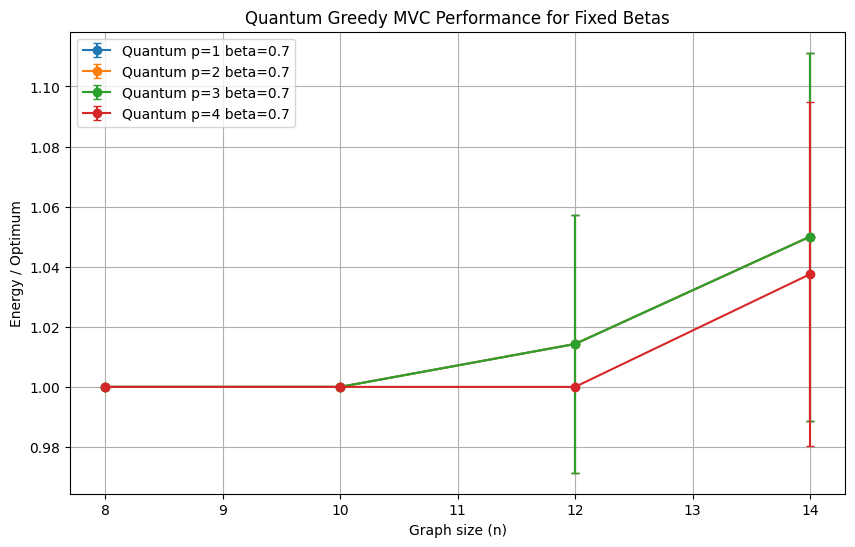

In [ ]:
plt.figure(figsize=(10,6))
for appr in approaches:
    plt.errorbar([8,10,12,14], results_mean[appr], yerr=results_std[appr],
                 label=appr, marker='o', capsize=3)
plt.xlabel("Graph size (n)")
plt.ylabel("Energy / Optimum")
plt.title("Quantum Greedy MVC Performance for Fixed Betas")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
results_mean

{'Quantum p=1 beta=0.7': [np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0142857142857142),
  np.float64(1.05)],
 'Quantum p=2 beta=0.7': [np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0142857142857142),
  np.float64(1.05)],
 'Quantum p=3 beta=0.7': [np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0142857142857142),
  np.float64(1.05)],
 'Quantum p=4 beta=0.7': [np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0375)]}

In [ ]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt

# -------------------------------------------------
# Experiment Parameters
# -------------------------------------------------

graph_sizes = [8,10,12,14,16, 18]
k = 40
degree = 3
case = "unweighted"
shots = None

p_list = [1, 2, 3, 4]
beta_cases = {
    "beta=None": None,
    "beta=pi/2": np.pi/2
}

# -------------------------------------------------
# Storage
# -------------------------------------------------

approaches = []
for p in p_list:
    for beta_label in beta_cases:
        approaches.append(f"Quantum p={p} {beta_label}")

results_mean = {appr: [] for appr in approaches}
results_std = {appr: [] for appr in approaches}

# -------------------------------------------------
# Experiment Loop
# -------------------------------------------------

for n in graph_sizes:

    print("\nGraph size:", n)

    ratios = {appr: [] for appr in approaches}

    for graph_seed in range(k):

        print("graph:", graph_seed)

        # generate connected graph
        while True:
            G = nx.erdos_renyi_graph(n, degree/n)
            if nx.is_connected(G):
                break

        # alternative graph model
        G = nx.random_regular_graph(degree, n)

        # node weights
        if case == "unweighted":
            c = {i: 1.0 for i in G.nodes()}
        else:
            c = {i: random.uniform(0.40, 0.70) for i in G.nodes()}

        # -------------------------------------------------
        # Optimal solution
        # -------------------------------------------------

        C_opt = mvc_exact_cplex(G, c)
        opt_cost = sum(c[i] for i in C_opt)

        #print("opt_cost =", opt_cost)

        # -------------------------------------------------
        # Quantum experiments
        # -------------------------------------------------

        for p in p_list:

            for beta_label, beta_val in beta_cases.items():

                energy = quantum_vertex_greedy(
                    G,
                    p=p,
                    shots=shots,
                    beta=beta_val,
                    tol=1e-8
                )

                appr = f"Quantum p={p} {beta_label}"

                ratios[appr].append(energy / opt_cost)

    # -------------------------------------------------
    # Statistics
    # -------------------------------------------------

    for appr in approaches:

        results_mean[appr].append(np.mean(ratios[appr]))
        results_std[appr].append(np.std(ratios[appr]))

# -------------------------------------------------
# Plot Results
# -------------------------------------------------



Graph size: 8
graph: 0
graph: 1
graph: 2
graph: 3
graph: 4
graph: 5
graph: 6
graph: 7
graph: 8
graph: 9
graph: 10
graph: 11
graph: 12
graph: 13
graph: 14
graph: 15
graph: 16
graph: 17
graph: 18
graph: 19
graph: 20
graph: 21
graph: 22
graph: 23
graph: 24
graph: 25
graph: 26
graph: 27
graph: 28
graph: 29
graph: 30
graph: 31
graph: 32
graph: 33
graph: 34
graph: 35
graph: 36
graph: 37
graph: 38
graph: 39

Graph size: 10
graph: 0


KeyboardInterrupt: 

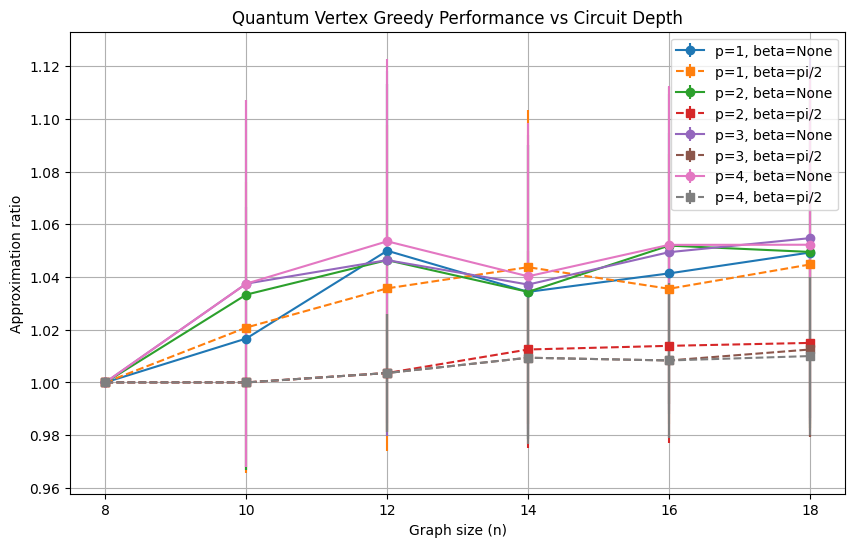

In [ ]:

plt.figure(figsize=(10,6))

for p in p_list:

    means_none = results_mean[f"Quantum p={p} beta=None"]
    std_none = results_std[f"Quantum p={p} beta=None"]

    means_pi = results_mean[f"Quantum p={p} beta=pi/2"]
    std_pi = results_std[f"Quantum p={p} beta=pi/2"]

    plt.errorbar(
        graph_sizes,
        means_none,
        yerr=std_none,
        marker='o',
        linestyle='-',
        label=f"p={p}, beta=None"
    )

    plt.errorbar(
        graph_sizes,
        means_pi,
        yerr=std_pi,
        marker='s',
        linestyle='--',
        label=f"p={p}, beta=pi/2"
    )

plt.xlabel("Graph size (n)")
plt.ylabel("Approximation ratio")
plt.title("Quantum Vertex Greedy Performance vs Circuit Depth")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
vertices,energy=Quadratic_rounding_quantum_greedy(G, c, c, p=4, shots=None, initial_beta=np.pi/4)
print(energy)

KeyboardInterrupt: 

In [ ]:
beta_values={i: 1 for i in c} # equal 
betas = {i: Parameter(f"β_{i}") for i in range(len(G.nodes()))}
fixed,energy=Commuting_quantum_greedy(
    G,
    c,
    betas,
    beta_values,
    p=4,
    shots=None,
)
print("final_energy",energy)
beta_values_init={i: np.pi/2 for i in c} # equal 
vertices,energy=Quadratic_quantum_greedy(
    G,
    c,
    c,
    beta_values_init,
    p=4,
    shots=None,
)
print(energy)
energy=quantum_vertex_greedy(
    G,
    p=4,
    shots=None,
    tol=1e-8
)
print(energy)

vertices,energy=Quadratic_rounding_quantum_greedy(G, c, c, p=4, shots=None, initial_beta=np.pi/4)
print(energy)


0.34581822597812656 0
0.3515693965093305 1
0.45270470834256077 2
0.4481896022450265 3
0.3656292007596318 4
0.36950431929968147 5
0.3620832602630217 6
0.4985767416638034 7
0.4904826544172283 8
0.4476320495710521 9
0.44725280336285433 10
0.35076596257937404 11
0.43386436804115436 12
0.4940162519167564 13
0.525798694859087 1
0.47932286702089655 2
0.5843805961335856 3
0.38254582586571045 4
0.38386576771035164 5
0.3792133028501261 6
0.48787536284377125 7
0.5079733692084918 8
0.449487726839602 9
0.44154589709222075 10
0.5186195961984791 11
0.42775320154310853 12
0.5181542095091891 13
0.49767963829694845 1
0.5025854657850443 2
0.6012516273154755 3
0.5625326236859239 4
0.5583319449118864 5
0.556350695549809 7
0.5307078505945739 8
0.43555823039502956 9
0.461663988406263 10
0.5383247759087536 11
0.4218016526241056 12
0.5228516473177977 13
0.4927188187908123 1
0.5749737123633346 2
0.6291712332533692 3
0.6574293711771494 4
0.5479615830549421 5
0.5818702804964273 7
0.5250708645625204 8
0.4525605970